In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.segmentation import active_contour
from skimage.filters import gaussian

In [4]:
import weompy

wimage = weompy.Image.load("test.wti")
image = np.array(wimage.getData()).reshape(wimage.getHeight(), wimage.getWidth())
image = np.round(256 * image / image.max())
print(image)

[[255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]
 ...
 [255. 255. 255. ... 250. 250. 250.]
 [255. 255. 255. ... 250. 250. 250.]
 [255. 255. 255. ... 250. 250. 250.]]


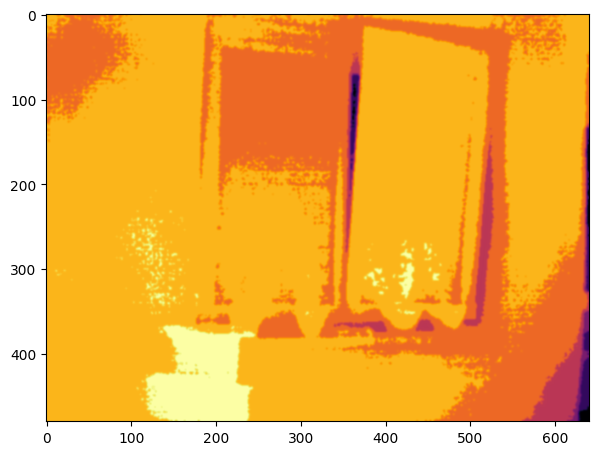

In [ ]:
smooth = gaussian(image, sigma=1)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(smooth, cmap="inferno")
plt.show()

In [ ]:
s = np.linspace(0, 2 * np.pi, 400)
x = smooth.shape[0] / 4 + 100 * np.cos(s)
y = smooth.shape[1] / 4 + 100 * np.sin(s)

init = np.array([x, y]).T

snake = active_contour(
    smooth,
    init,
    alpha=0.05,
    beta=5,
    gamma=0.01,
    max_num_iter=250000
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(smooth, cmap="inferno")
ax.plot(init[:, 0], init[:, 1], "--r", label="Počáteční kontura")
ax.plot(snake[:, 0], snake[:, 1], "-b", label="Final Snake")
ax.legend()
plt.show()